<a href="https://colab.research.google.com/github/kkumarisfdc/Kiran-s_Portfolio/blob/main/Exploring_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [ ]:
from numpy.random.mtrand import poisson
#load Biological Data
#Simulated gene expression dataset
np.random.seed(42)
genes =[f"Gene_(i)" for i in range(1,101)]
samples = [f"Sample_(i)" for i in range(1,11)]

data  = np.random.poisson(lam = 50, size=(100,10))
df= pd.DataFrame(data, index=genes, columns=samples)
df.head()


,Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i)
Gene_(i),47,55,42,52,58,43,46,49,52,45
Gene_(i),49,43,52,52,46,54,40,45,46,51
Gene_(i),64,52,38,33,48,58,45,41,56,54
Gene_(i),56,47,59,46,46,55,60,40,56,56
Gene_(i),50,46,61,48,44,45,63,53,57,60


In [ ]:
df.shape

(100, 10)

In [ ]:
df.describe()

,Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i),Sample_(i)
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,50.470000,49.720000,49.900000,49.450000,49.430000,50.590000,50.07000,49.060000,48.780000,50.540000
std,6.899649,8.084253,7.169661,6.919997,8.189985,6.783961,7.44577,7.441109,7.221712,6.561935
min,34.000000,30.000000,36.000000,30.000000,31.000000,35.000000,35.00000,33.000000,32.000000,29.000000
25%,46.000000,43.750000,44.000000,45.750000,45.000000,45.750000,44.00000,44.000000,45.000000,47.000000
50%,50.500000,49.500000,50.500000,50.000000,49.000000,50.000000,51.00000,49.000000,49.000000,51.000000
75%,55.000000,55.250000,54.250000,53.000000,54.000000,55.250000,55.00000,54.000000,54.000000,54.250000
max,67.000000,71.000000,67.000000,71.000000,70.000000,67.000000,69.00000,72.000000,72.000000,69.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, Gene_(i) to Gene_(i)
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Sample_(i)  100 non-null    int64
 1   Sample_(i)  100 non-null    int64
 2   Sample_(i)  100 non-null    int64
 3   Sample_(i)  100 non-null    int64
 4   Sample_(i)  100 non-null    int64
 5   Sample_(i)  100 non-null    int64
 6   Sample_(i)  100 non-null    int64
 7   Sample_(i)  100 non-null    int64
 8   Sample_(i)  100 non-null    int64
 9   Sample_(i)  100 non-null    int64
dtypes: int64(10)
memory usage: 12.7+ KB


In [ ]:
df.isnull().sum().sum()

np.int64(0)

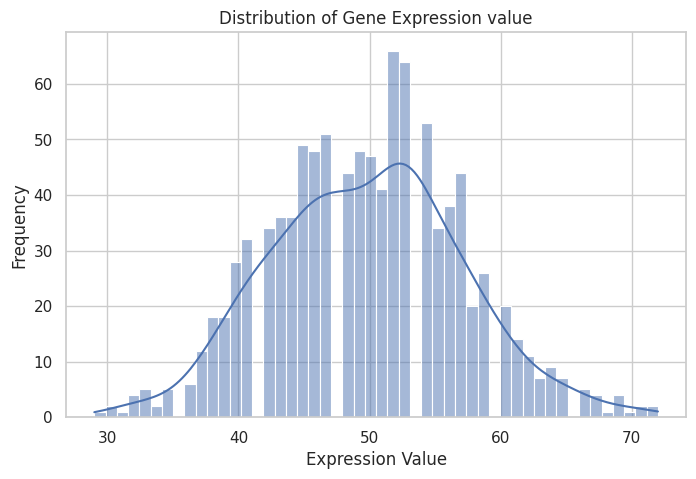

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df.values.flatten(),bins=50,kde=True)
plt.title("Distribution of Gene Expression value")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")
plt.show()

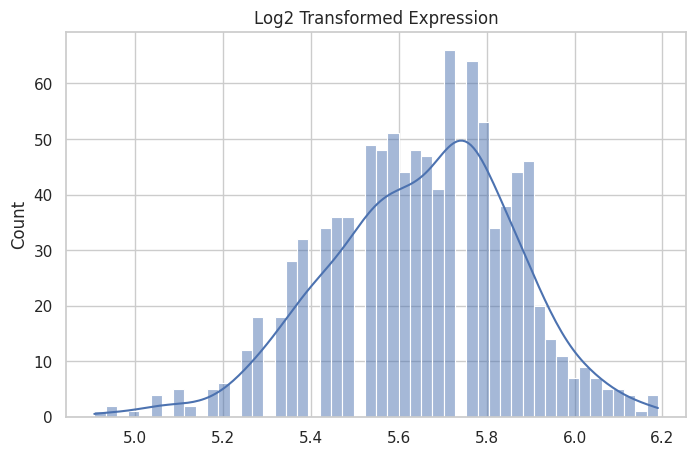

In [ ]:
df_log= np.log2(df+1)
plt.figure(figsize=(8,5))
sns.histplot(df_log.values.flatten(),bins =50, kde=True)
plt.title("Log2 Transformed Expression")
plt.show()

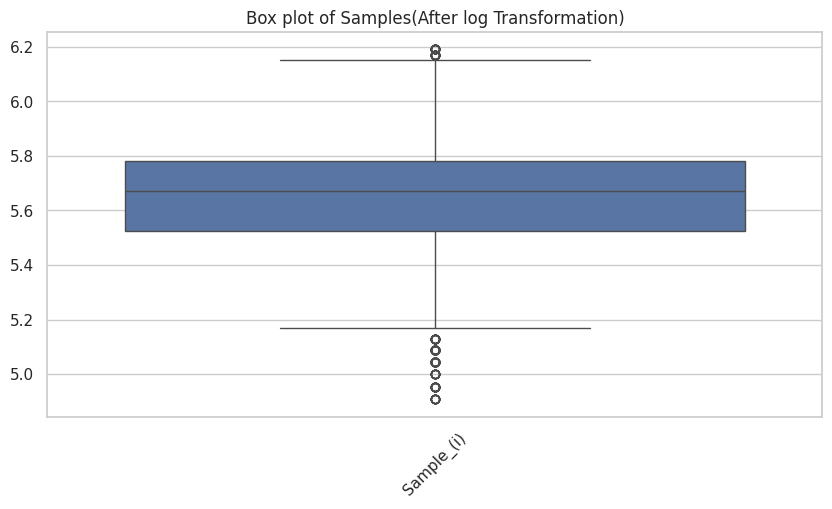

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_log)
plt.xticks(rotation=45)
plt.title("Box plot of Samples(After log Transformation)")
plt.show()

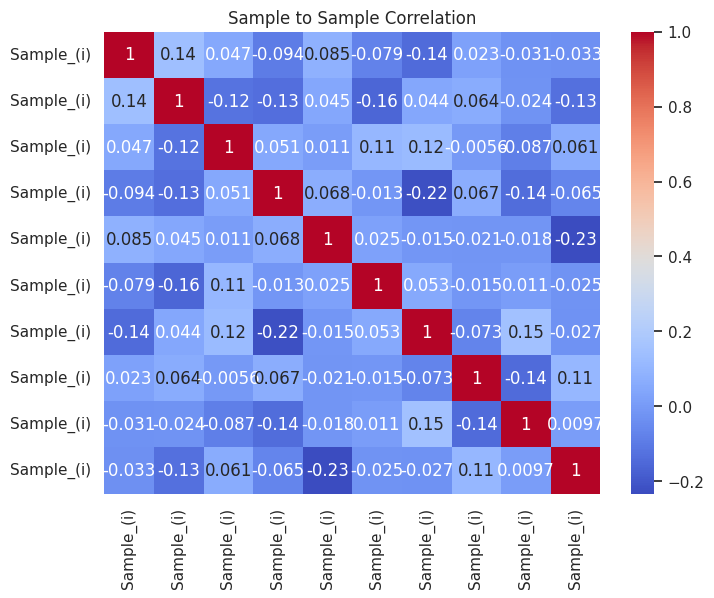

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_log.corr(),annot=True, cmap="coolwarm")
plt.title("Sample to Sample Correlation")
plt.show()


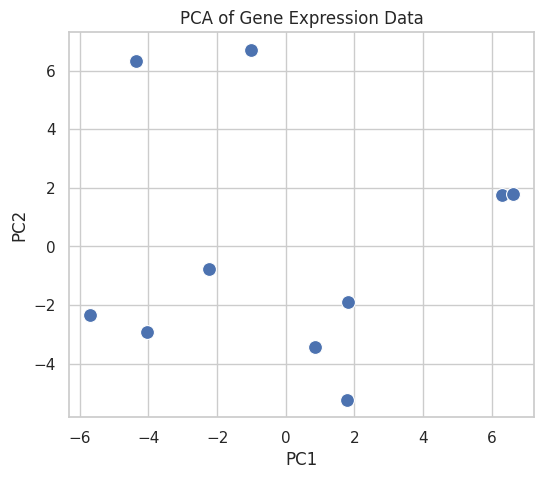

In [ ]:
from  sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(df_log.T)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_result, columns=["PC1","PC2"],index=df.columns)
plt.figure(figsize=(6,5))
sns.scatterplot(x="PC1",y="PC2",data=pca_df,s=100)
plt.title("PCA of Gene Expression Data")
plt.show()
